In [ ]:
!pip install --force-reinstall "fastcore>=1.11.0" "protobuf<5.0.0" "fsspec==2025.3.0" "rich<14"
!pip install --upgrade --force-reinstall smart_open
!pip install fsspec==2025.3.0
!pip install spacy
!python -m spacy download en_core_web_sm

from gensim.models import Word2Vec
import pandas as pd
import numpy as np
import json
# from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("done package downlaods...")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 4.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: pygments
    Found existing installation: Pygments 2.19.2
    Uninstalling Pygments-2.19.2:
      Successfully uninstalled Pygments-2.19.2
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0rc2
    Uninstalling packaging-

In [ ]:
# config
WORD2VEC_MODEL = "recipe_engine.kv"
KMEANS_MODEL = "recipe_clusterer.joblib"
PCA_MODEL = "recipe_pca.joblib"
SEARCH_INDEX = "recipe_search_index.npy"
UI_CSV = "recipes_ui.csv"
BIGRAM_MODEL = "bigram_model.pkl"
BUNDLE_ZIP = "recipe_ai_model_bundle.zip"


In [2]:
import pandas as pd
import glob

# path = glob.glob('/kaggle/input/**/Recipe*.csv', recursive=True)[0]
path = "/kaggle/input/datasets/paultimothymooney/recipenlg/RecipeNLG_dataset.csv"
data_frame = pd.read_csv(path)

print(f"Loaded file from: {path}")

Loaded file from: /kaggle/input/datasets/paultimothymooney/recipenlg/RecipeNLG_dataset.csv


In [ ]:
import json

# Parse NER column first
tokenized_ingredients = data_frame["NER"].apply(lambda x: json.loads(x))

# Now split each ingredient into words
tokenized_ingredients = [
    [word for ingredient in recipe for word in ingredient.split()]
    for recipe in tokenized_ingredients
]

print(f"Sample after word splitting: {tokenized_ingredients[:3]}")

Mean length of recipes: 8
Sample after word splitting: [['brown', 'sugar', 'milk', 'vanilla', 'nuts', 'butter', 'bite', 'size', 'shredded', 'rice', 'biscuits'], ['beef', 'chicken', 'breasts', 'cream', 'of', 'mushroom', 'soup', 'sour', 'cream'], ['frozen', 'corn', 'cream', 'cheese', 'butter', 'garlic', 'powder', 'salt', 'pepper']]


In [ ]:
# Filter malformed recipes (fewer than 3 tokens)
valid_mask = [len(t) >= 3 for t in tokenized_ingredients]
tokenized_ingredients = [t for t in tokenized_ingredients if len(t) >= 3]
data_frame = data_frame[valid_mask].reset_index(drop=True)

print(f"Filtered recipes: {len(tokenized_ingredients)} remaining")

# Calculate mean length on filtered data
mean_length = int(sum(len(t) for t in tokenized_ingredients) / len(tokenized_ingredients))
print(f"Mean length of recipes: {mean_length}")


In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def lemmatize_tokens_batch(token_lists, batch_size=1000):
    lemmatized_all = []
    
    for tokens in token_lists:
        if not tokens:
            lemmatized_all.append([])
            continue
        
        # batch lemmatize all tokens (no bigrams yet)
        if tokens:
            lemmatized_map = {}
            docs = list(nlp.pipe(tokens, batch_size=batch_size))
            for i, doc in enumerate(docs):
                original = tokens[i]
                lemmatized_map[original] = doc[0].lemma_ if len(doc) > 0 else original
            
            result = [lemmatized_map.get(token, token) for token in tokens if token]
            lemmatized_all.append(result)
        else:
            lemmatized_all.append([])
    
    return lemmatized_all

print("lemmatizing tokens...")
tokenized_ingredients = lemmatize_tokens_batch(tokenized_ingredients)

print(f"sample after lemmatization: {tokenized_ingredients[:3]}")

Found 581 unique bigrams
Examples: ['unflavored_gelatine', 'chocolate_chip', 'Marshmallow_Creme', 'cashew_pieces', 'cut_rhubarb', 'nonfat_yogurt', 'walnut_pieces', 'biscuit_dough', 'bite-size_pieces', 'pie_filling', 'bulk_sausage', 'Vanilla_Pudding', 'shredded_monterey', 'cranberry-orange_relish', 'game_hens', 'pork_loin', 'caramel_candies', 'boneless_skinless', 'pecan_halves', 'penne_pasta', 'almond_slivers', 'ham_bone', 'fully_cooked', 'solid_pack', 'veal_shoulder', 'bite_size', 'salami_pepperoni', 'broccoli_spears', 'gumbo_file', 'Wish-Bone_Italian']


In [ ]:
# Bigram training
from gensim.models.phrases import Phrases, Phraser

bigram = Phrases(tokenized_ingredients, min_count=50, threshold=5, delimiter='_')
bigram_model = Phraser(bigram)
tokenized_ingredients = [bigram_model[tokens] for tokens in tokenized_ingredients]

sample_bigrams = set()
for tokens in tokenized_ingredients[:10000]:
    sample_bigrams.update([t for t in tokens if '_' in t])

print(f"Found {len(sample_bigrams)} unique bigrams")
print(f"Examples: {list(sample_bigrams)[:30]}")


In [ ]:
# Save bigram model for inference
import joblib

joblib.dump(bigram_model, BIGRAM_MODEL)
print(f"Bigram model saved to {BIGRAM_MODEL}")


In [ ]:
import time
from gensim.models import Word2Vec

start = time.time()

w2v = Word2Vec(
    sentences=tokenized_ingredients,
    vector_size=100,
    window=mean_length,
    min_count=3,  # Changed from 1 to 3 (thesis requirement)
    workers=6,
    epochs=50,
    sg=0  # CBOW selected for computational efficiency on large corpora and superior handling of high-frequency ingredients
)

print(f"trained in {time.time() - start:.2f}s")

trained in 747.86s


In [6]:
import numpy as np

def recipe_vector(tokens, model):
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(
vecs, axis=0) if vecs else np.zeros(model.vector_size)


embeddings = np.array([recipe_vector(t, w2v) for t in tokenized_ingredients])

print(f"Embeddings shape before PCA: {embeddings.shape}")
print(f"Word2Vec vector size: {w2v.vector_size}")
print("Finished")

Embeddings shape before PCA: (2231142, 100)
Word2Vec vector size: 100
Finished


In [7]:
from sklearn.decomposition import PCA
import time

start = time.time()

# Apply PCA to reduce from 100D to 50D
pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)

print(f"PCA completed in {time.time() - start:.2f}s")
print(f"Original shape: {embeddings.shape}")
print(f"Reduced shape: {embeddings_pca.shape}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.3f}")

# Use embeddings_pca for all clustering from now on
embeddings = embeddings_pca

PCA completed in 1.87s
Original shape: (2231142, 100)
Reduced shape: (2231142, 50)
Variance retained: 0.927


In [ ]:
# Elbow method - WCSS calculation for optimal k selection
from cuml.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

wcss = []
k_range_elbow = range(2, 16)

print("Calculating WCSS for elbow method...")
for k in k_range_elbow:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(embeddings_pca)
    # Get inertia (WCSS) - convert to CPU if needed
    inertia = km.inertia_
    if hasattr(inertia, 'get'):
        inertia = inertia.get()
    wcss.append(float(inertia))
    print(f"k={k}: WCSS={inertia:.2f}")

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range_elbow, wcss, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

print(f"\nWCSS values: {dict(zip(k_range_elbow, wcss))}")


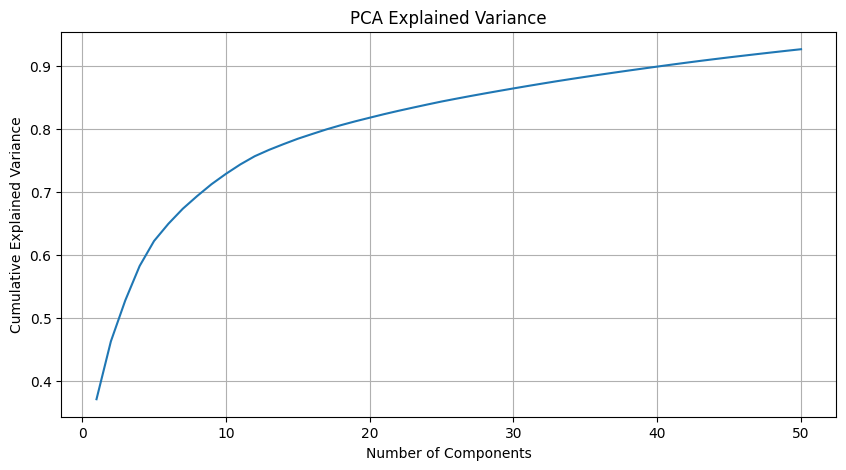

In [10]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from cuml.cluster import KMeans
import numpy as np

# Convert to CPU for metrics if using cuml
if hasattr(embeddings_pca, 'get'):
    emb_cpu = embeddings_pca.get()
else:
    emb_cpu = embeddings_pca

scores = {'silhouette': {}, 'dbi': {}, 'chi': {}}
k_range = range(2, 16)

# Sample for silhouette (too slow on full dataset)
sample_size = 20000
indices = np.random.choice(emb_cpu.shape[0], sample_size, replace=False)
emb_sample = emb_cpu[indices]

for k in k_range:
    
    print(f"Testing k={k}...")
    km = KMeans(n_clusters=k, random_state=42)
    
    # Fit on full data
    labels_all = km.fit_predict(embeddings_pca)
    if hasattr(labels_all, 'get'):
        labels_all = labels_all.get()
    
    # Silhouette on sample (O(n^2) complexity)
    labels_sample = labels_all[indices]
    scores['silhouette'][k] = silhouette_score(emb_sample, labels_sample)
    
    # DBI and CHI on full data (faster)
    scores['dbi'][k] = davies_bouldin_score(emb_cpu, labels_all)
    scores['chi'][k] = calinski_harabasz_score(emb_cpu, labels_all)
    
    print(f"  Silhouette: {scores['silhouette'][k]:.4f}")
    print(f"  DBI: {scores['dbi'][k]:.4f}")
    print(f"  CHI: {scores['chi'][k]:.1f}")

print("\n=== SUMMARY ===")
print(f"Best Silhouette (higher=better): k={max(scores['silhouette'], key=scores['silhouette'].get)}")
print(f"Best DBI (lower=better): k={min(scores['dbi'], key=scores['dbi'].get)}")
print(f"Best CHI (higher=better): k={max(scores['chi'], key=scores['chi'].get)}")

Testing k=2...
  Silhouette: 0.3037
  DBI: 1.3364
  CHI: 1103388.3
Testing k=3...
  Silhouette: 0.2963
  DBI: 1.3367
  CHI: 698736.7
Testing k=4...
  Silhouette: 0.2396
  DBI: 1.7524
  CHI: 552199.6
Testing k=5...
  Silhouette: 0.1804
  DBI: 1.9437
  CHI: 511993.3
Testing k=6...
  Silhouette: 0.1614
  DBI: 1.9589
  CHI: 446317.2
Testing k=7...
  Silhouette: 0.1270
  DBI: 2.1596
  CHI: 400621.3
Testing k=8...
  Silhouette: 0.1236
  DBI: 2.1652
  CHI: 363445.3
Testing k=9...
  Silhouette: 0.1243
  DBI: 2.0981
  CHI: 337129.1
Testing k=10...
  Silhouette: 0.1233
  DBI: 2.1367
  CHI: 308104.4
Testing k=11...
  Silhouette: 0.1115
  DBI: 2.1105
  CHI: 290627.4
Testing k=12...
  Silhouette: 0.1213
  DBI: 2.0970
  CHI: 269941.5
Testing k=13...
  Silhouette: 0.1033
  DBI: 2.2438
  CHI: 256925.5
Testing k=14...
  Silhouette: 0.1028
  DBI: 2.2152
  CHI: 243226.6
Testing k=15...
  Silhouette: 0.1068
  DBI: 2.1032
  CHI: 230089.7

=== SUMMARY ===
Best Silhouette (higher=better): k=2
Best DBI (lower

In [ ]:
# Assuming you've picked a K (let's try k=3 based on your scores)
final_k = 3
km = KMeans(n_clusters=final_k, random_state=42)

# If embeddings is a cupy array, km.fit_predict returns a cupy array.
# If embeddings is a numpy array, it returns a numpy array.
labels = km.fit_predict(embeddings)

# Check if it needs .get() or not dynamically
if hasattr(labels, 'get'):
    data_frame['cluster'] = labels.get()
else:
    data_frame['cluster'] = labels

# Print a few samples from each cluster to see if they make sense
for i in range(final_k):
    print(f"\n--- Cluster {i} Samples ---")
    # Using 'title' or 'NER' (ingredients) usually helps identify the cluster theme
    if 'title' in data_frame.columns:
        print(data_frame[data_frame['cluster'] == i]['title'].head(10))
    else:
        print(data_frame[data_frame['cluster'] == i].head(10))

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# silhouette
axes[0].plot(list(scores['silhouette'].keys()), list(scores['silhouette'].values()), 'o-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('silhouette score')
axes[0].set_title('silhouette (higher = better)')
axes[0].grid(True)

# DBI
axes[1].plot(list(scores['dbi'].keys()), list(scores['dbi'].values()), 'o-', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('davies-bouldin index')
axes[1].set_title('DBI (lower = better)')
axes[1].grid(True)

# CHI
axes[2].plot(list(scores['chi'].keys()), list(scores['chi'].values()), 'o-', color='green')
axes[2].set_xlabel('k')
axes[2].set_ylabel('calinski-harabasz index')
axes[2].set_title('CHI (higher = better)')
axes[2].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
from cuml.cluster import KMeans as CuMLKMeans
from sklearn.cluster import KMeans as SKLearnKMeans

# use cuML for fast clustering
final_k = 2
km_cuml = CuMLKMeans(n_clusters=final_k, random_state=42)

labels = km_cuml.fit_predict(embeddings)

if hasattr(labels, 'get'):
    data_frame['cluster'] = labels.get()
else:
    data_frame['cluster'] = labels

# convert to sklearn for CPU compatibility
km = SKLearnKMeans(n_clusters=final_k, random_state=42)
km.cluster_centers_ = km_cuml.cluster_centers_.get() if hasattr(km_cuml.cluster_centers_, 'get') else km_cuml.cluster_centers_
km._n_features_in = embeddings.shape[1]
km.n_features_in_ = embeddings.shape[1]

print("=== cluster distribution ===")
print(data_frame['cluster'].value_counts().sort_index())

for i in range(final_k):
    print(f"\n--- cluster {i} samples ---")
    print(data_frame[data_frame['cluster'] == i]['title'].head(20).tolist())


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# sample for t-SNE (too slow on full dataset)
sample_size = 5000
sample_idx = np.random.choice(len(embeddings), sample_size, replace=False)
embeddings_sample = embeddings[sample_idx]
labels_sample = data_frame['cluster'].iloc[sample_idx].values

# t-SNE to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings_sample)

# plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                     c=labels_sample, cmap='viridis', alpha=0.6, s=10)
plt.colorbar(scatter, label='cluster')
plt.title('t-SNE visualization of recipe clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
from collections import Counter

# top ingredients per cluster
for i in range(final_k):
    cluster_recipes = data_frame[data_frame['cluster'] == i]
    all_ingredients = []
    
    for recipe_tokens in cluster_recipes.index[:10000]:  # sample 10k per cluster
        ingredients = tokenized_ingredients[recipe_tokens]
        all_ingredients.extend(ingredients)
    
    top_ingredients = Counter(all_ingredients).most_common(20)
    
    print(f"\n=== cluster {i} top ingredients ===")
    for ingredient, count in top_ingredients:
        print(f"{ingredient}: {count}")


In [ ]:
import joblib

w2v.wv.save(WORD2VEC_MODEL)
joblib.dump(km, KMEANS_MODEL)
joblib.dump(pca, PCA_MODEL)

In [ ]:
import numpy as np

all_vectors = []

for tokens in tokenized_ingredients:
    vecs = [w2v.wv[w] for w in tokens if w in w2v.wv]
    if vecs:
        all_vectors.append(np.mean(vecs, axis=0))
    else:
        all_vectors.append(np.zeros(100))

np.save(SEARCH_INDEX, np.array(all_vectors))

In [ ]:
# Export recipe data with clusters
data_frame[['title', 'ingredients', 'directions', 'cluster']].to_csv(UI_CSV, index=False)
print(f"Recipe data exported to {UI_CSV}")

# Create deployment bundle with all model files
import zipfile
import os

# All files needed for inference
files_to_zip = [
    WORD2VEC_MODEL,
    f"{WORD2VEC_MODEL}.vectors.npy",
    KMEANS_MODEL,
    PCA_MODEL,
    BIGRAM_MODEL,
    SEARCH_INDEX,
    UI_CSV
]

print(f"\nCreating deployment bundle: {BUNDLE_ZIP}")
print("=" * 50)

added_files = []
missing_files = []

with zipfile.ZipFile(BUNDLE_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for file in files_to_zip:
        if os.path.exists(file):
            zf.write(file)
            file_size = os.path.getsize(file) / (1024 * 1024)  # Size in MB
            print(f"✓ {file:40s} ({file_size:.2f} MB)")
            added_files.append(file)
        else:
            print(f"✗ {file:40s} NOT FOUND - SKIPPING")
            missing_files.append(file)

print("=" * 50)
print(f"\nBundle created: {BUNDLE_ZIP}")
print(f"Files added: {len(added_files)}/{len(files_to_zip)}")

if missing_files:
    print(f"\n⚠ WARNING: {len(missing_files)} file(s) missing:")
    for file in missing_files:
        print(f"  - {file}")
else:
    print("✓ All required files included!")
    
bundle_size = os.path.getsize(BUNDLE_ZIP) / (1024 * 1024)
print(f"\nBundle size: {bundle_size:.2f} MB")

In [ ]:
import os

if os.path.exists(BUNDLE_ZIP):
    size_mb = os.path.getsize(BUNDLE_ZIP) / (1024 * 1024)
    print(f"file: {BUNDLE_ZIP}")
    print(f"size: {size_mb:.2f} MB")
else:
    print("file not found")